In [4]:
#Mount Colab to Google Drive to save and share files
from google.colab import drive
import os
drive.mount('/content/drive')
%cd /content/drive/MyDrive/MOR-project
!ls

!python3 -m pip install vtk
!python3 -m pip install pypolydim
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
#import sys
#sys.path.insert(0, "/content/drive/MyDrive/MOR-project")
import other_utilities as other_ut



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MOR-project
Export	Meshes	other_utilities.py  __pycache__  Q1.ipynb


In [5]:
#Initalize parameters
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

#All export folders path
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

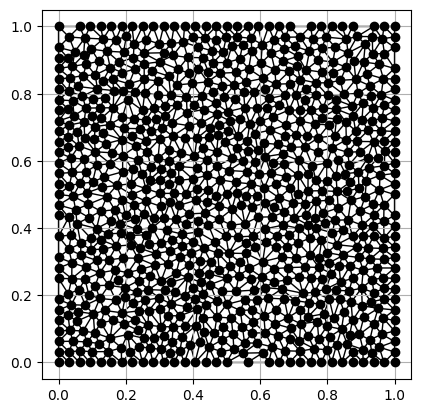

In [6]:
#Define the domain [0,1]x[0,1]
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

#Define the mesh
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular 
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc     
method_order = 1
# 0.05 gives the saved small test problem: P dofs = 23, U dofs = 45.
# Use a smaller value only if you want to recompute all snapshots on a finer mesh.
mesh_size = 0.001

mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

#plot the mesh
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [7]:
print("Vertex markers:", np.unique(mesh_data.cell0_d_markers))
print("Edge markers:", np.unique(mesh_data.cell1_d_markers))

Vertex markers: [0 1 2 3 4 5 6 7 8]
Edge markers: [0 5 6 7 8]


In [8]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet, #fix pressure at (0,0) to 0
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [9]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [10]:
#amount of DOF's

pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


In [11]:
#Define the non affine source term

In [12]:
#assemble the FEM matrices
def pressure_strong_function(marker, x, y, z):
    return 0.0

def speed_x_strong_function(marker, x, y, z):
    return 0.0

def speed_y_strong_function(marker, x, y, z):
    return 0.0

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_mesh_dofs_info,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_strong_function
)

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_x_strong_function
)

u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_y_strong_function
)

strong_solution = np.concatenate([u_x_strong, u_y_strong, p_strong])

In [13]:
#check the dimensions 

print("strong_solution shape:", strong_solution.shape)

print("speed_n_dofs:", speed_n_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("total strong expected:", 2 * speed_n_strongs + pressure_n_strongs)

strong_solution shape: (469,)
speed_n_dofs: 2966
pressure_n_dofs: 829
total strong expected: 469


In [14]:
def one_term(x, y, z):  
    return 1.0

def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])


A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

A_speed = other_ut.make_np_sparse(A_operator.operator_dofs)

J_A_x = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [0, 0]
)

J_A_y = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [speed_n_dofs, speed_n_dofs]
)

J_A_Base = J_A_x + J_A_y

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_B = -J_B_x - J_B_y - J_BT_x - J_BT_y

# Velocity mass matrix: int u v dx
M_speed_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

M_speed = other_ut.make_np_sparse(M_speed_operator.operator_dofs)

# Velocity H1 inner product:
# ||u||^2 + ||grad u||^2 for both u_x and u_y
X_u = scipy.sparse.block_diag(
    [A_speed + M_speed, A_speed + M_speed],
    format="csr"
)

# Pressure mass matrix: int p q dx
M_p_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_dofs_data,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_reference_element_data,
    one_term
)

M_p = other_ut.make_np_sparse(M_p_operator.operator_dofs)

# Pressure L2 inner product
X_p = M_p

print("A_speed shape:", A_speed.shape)
print("M_speed shape:", M_speed.shape)
print("X_u shape:", X_u.shape)
print("X_p shape:", X_p.shape)

A_speed shape: (2966, 2966)
M_speed shape: (2966, 2966)
X_u shape: (5932, 5932)
X_p shape: (829, 829)


In [15]:
def assemble_source(mu1):
    def f_1_function(x, y, z):
        return -(
            mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * x)
            - mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * y) * np.cos(mu1 * np.pi * y) \
        + mu1 * np.pi * np.cos(mu1 * np.pi * x) * np.cos(mu1 * np.pi * y)

    def f_2_function(x, y, z):
        return -(
            -mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * y)
            + mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * x) * np.cos(mu1 * np.pi * x) \
        - mu1 * np.pi * np.sin(mu1 * np.pi * x) * np.sin(mu1 * np.pi * y)

    f_1 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_1_function
    )

    f_2 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_2_function
    )

    f_S = np.concatenate([
        f_1,
        f_2,
        np.zeros(pressure_n_dofs)
    ])

    return f_S

def assemble_stokes_matrix(mu0):
    J_S = mu0 * J_A_Base + J_B
    return J_S


In [16]:
#use same seed for now
# Use the same seed so the training set is reproducible.
np.random.seed(1)

# Parameter domain: mu0 in [0.1, 10.0], mu1 in [1.0, 3.0].
mu0_range = [0.1, 10.0]
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

# Main random coverage of the complete parameter domain.
num_uniform = 300

# Extra random samples for low mu0, where the solution can change rapidly.
num_low_mu0 = 150

# Extra random samples for high mu0 over the full mu1 range.
# This is added because the worst POD-NN errors appeared near large mu0.
num_high_mu0 = 250

# Extra samples exactly on the mu1 boundaries, for all mu0 values.
num_mu1_edges = 100

# Random samples over the full domain.
training_uniform = np.random.uniform(
    low=P[:, 0],
    high=P[:, 1],
    size=(num_uniform, P.shape[0])
)

# Random enrichment near the low-mu0 side of the domain.
training_low_mu0 = np.column_stack([
    np.random.uniform(0.1, 1.0, size=num_low_mu0),
    np.random.uniform(1.0, 3.0, size=num_low_mu0)
])

# Random enrichment near the high-mu0 side of the domain, across all mu1.
training_high_mu0 = np.column_stack([
    np.random.uniform(7.0, 10.0, size=num_high_mu0),
    np.random.uniform(1.0, 3.0, size=num_high_mu0)
])

# Samples on the lower and upper mu1 boundaries.
training_mu1_edges = np.column_stack([
    np.random.uniform(0.1, 10.0, size=num_mu1_edges),
    np.random.choice([1.0, 3.0], size=num_mu1_edges)
])

# Structured low-mu0 grid. This protects the low-mu0 region without
# letting it dominate the whole training set too much.
mu0_low_grid = np.array([0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0])
mu1_grid = np.linspace(1.0, 3.0, 15)
MU0_LOW, MU1_LOW = np.meshgrid(mu0_low_grid, mu1_grid, indexing="ij")
training_low_grid = np.column_stack([MU0_LOW.ravel(), MU1_LOW.ravel()])

# Structured high-mu0 grid over the full mu1 interval.
# This directly improves coverage near mu0 = 10 for every mu1 value.
mu0_high_grid = np.array([5.0, 6.5, 8.0, 9.0, 10.0])
mu1_high_grid = np.linspace(1.0, 3.0, 17)
MU0_HIGH, MU1_HIGH = np.meshgrid(mu0_high_grid, mu1_high_grid, indexing="ij")
training_high_grid = np.column_stack([MU0_HIGH.ravel(), MU1_HIGH.ravel()])

# Dense samples on and near the minimum-mu0 boundary.
mu0_near_min = np.array([0.1, 0.125, 0.15, 0.2, 0.3])
mu1_dense = np.linspace(1.0, 3.0, 21)
MU0_EDGE, MU1_EDGE = np.meshgrid(mu0_near_min, mu1_dense, indexing="ij")
training_near_mu0_min = np.column_stack([MU0_EDGE.ravel(), MU1_EDGE.ravel()])

# Extra line exactly at mu0 = 0.1.
training_mu0_min_edge = np.column_stack([
    np.full(31, 0.1),
    np.linspace(1.0, 3.0, 31)
])

# Exact boundary and diagnostic points that should always be present.
training_boundary = np.array([
    [0.1, 1.0], [0.1, 1.5], [0.1, 2.0], [0.1, 2.5], [0.1, 3.0],
    [0.2, 1.0], [0.2, 2.0], [0.2, 3.0],
    [0.5, 1.0], [0.5, 2.0], [0.5, 3.0],
    [1.0, 1.0], [1.0, 2.0], [1.0, 3.0],
    [5.0, 1.0], [5.0, 1.5], [5.0, 2.0], [5.0, 2.5], [5.0, 3.0],
    [7.5, 1.0], [7.5, 1.5], [7.5, 2.0], [7.5, 2.5], [7.5, 3.0],
    [10.0, 1.0], [10.0, 1.5], [10.0, 2.0], [10.0, 2.5], [10.0, 3.0],
])

training_set = np.vstack([
    training_uniform,
    training_low_mu0,
    training_high_mu0,
    training_mu1_edges,
    training_low_grid,
    training_high_grid,
    training_near_mu0_min,
    training_mu0_min_edge,
    training_boundary
])

# Remove exact duplicate grid/boundary points so repeated FOM solves are avoided.
training_set = np.unique(np.round(training_set, decimals=12), axis=0)
snapshot_num = training_set.shape[0]

print("training_set shape:", training_set.shape)
print(training_set)



training_set shape: (1108, 2)
[[ 0.1         1.        ]
 [ 0.1         1.06666667]
 [ 0.1         1.1       ]
 ...
 [10.          2.75      ]
 [10.          2.875     ]
 [10.          3.        ]]


In [17]:

def solve_fom(mu0, mu1):
    residual_norm = 1.0
    solution_norm = 1.0
    newton_tol = 1.0e-5
    max_iterations = 10
    num_iteration = 1


    # starting guess on initial condition

    def speed_x_initial_condition(x, y, z):  
        return 0.0

    def speed_y_initial_condition(x, y, z):  
        return 0.0

    def pressure_initial_condition(x, y, z):  
        return 0.0

    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_x_initial_condition).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_y_initial_condition).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    pressure_initial_condition).function_dofs

    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)


    #assemble and update source term with mu1
    f_S = assemble_source(mu1)

    #Update J_S with mu0
    J_S = assemble_stokes_matrix(mu0)
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_y_numeric,
            u_x_strong,
            u_y_strong
        )

        J_C = other_ut.make_np_sparse(
            c_operator.convective_operator.operator_dofs,
            [tot_dofs, tot_dofs],
            [0, 0]
        )

        f_C = np.concatenate([
            c_operator.convective_rhs,
            np.zeros(pressure_n_dofs)
        ])

        J_f = f_S - f_C - J_S @ u_k

        du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

        u_k = u_k + du

        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2 * speed_n_dofs]
        dp = du[2 * speed_n_dofs:]

        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_k[2 * speed_n_dofs:]

        du_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_x,
            du_x_strong
        )

        du_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_y,
            du_y_strong
        )

        dp_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            dp,
            dp_strong
        )

        u_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_x_strong
        )

        u_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_y_numeric,
            u_y_strong
        )

        p_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            p_numeric,
            p_strong
        )

        solution_norm = np.sqrt(
            u_x_norm_L2.numeric_norm_l2**2 +
            u_y_norm_L2.numeric_norm_l2**2 +
            p_norm_L2.numeric_norm_l2**2
        )

        residual_norm = np.sqrt(
            du_x_norm_L2.numeric_norm_l2**2 +
            du_y_norm_L2.numeric_norm_l2**2 +
            dp_norm_L2.numeric_norm_l2**2
        )
                
        num_iteration = num_iteration + 1


    info = {
        "mu0": mu0,
        "mu1": mu1,
        "iterations": num_iteration - 1,
        "final_ratio": residual_norm / solution_norm,
        "converged": residual_norm <= newton_tol * solution_norm
    }

    return u_k, u_x_numeric, u_y_numeric, p_numeric, info
    

In [ ]:
snapshot_matrix = []
info_list = []

import time
import pandas as pd

offline_cost_pod_galerkin = {}

start = time.perf_counter()

for i, mu in enumerate(training_set):
    mu0 = mu[0]
    mu1 = mu[1]

    print(f"Snapshot {i+1}/{snapshot_num}: mu0={mu0:.4f}, mu1={mu1:.4f}")

    u_k, u_x_numeric, u_y_numeric, p_numeric, info = solve_fom(mu0, mu1)

    snapshot_matrix.append(np.copy(u_k))
    info_list.append(info)

snapshot_matrix = np.array(snapshot_matrix)

S_u = snapshot_matrix[:, :2 * speed_n_dofs]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]

print("S_u shape:", S_u.shape)
print("S_p shape:", S_p.shape)


Snapshot 1/1108: mu0=0.1000, mu1=1.0000
Snapshot 2/1108: mu0=0.1000, mu1=1.0667
Snapshot 3/1108: mu0=0.1000, mu1=1.1000
Snapshot 4/1108: mu0=0.1000, mu1=1.1333
Snapshot 5/1108: mu0=0.1000, mu1=1.1429
Snapshot 6/1108: mu0=0.1000, mu1=1.2000
Snapshot 7/1108: mu0=0.1000, mu1=1.2667
Snapshot 8/1108: mu0=0.1000, mu1=1.2857
Snapshot 9/1108: mu0=0.1000, mu1=1.3000
Snapshot 10/1108: mu0=0.1000, mu1=1.3333
Snapshot 11/1108: mu0=0.1000, mu1=1.4000
Snapshot 12/1108: mu0=0.1000, mu1=1.4286
Snapshot 13/1108: mu0=0.1000, mu1=1.4667
Snapshot 14/1108: mu0=0.1000, mu1=1.5000
Snapshot 15/1108: mu0=0.1000, mu1=1.5333
Snapshot 16/1108: mu0=0.1000, mu1=1.5714
Snapshot 17/1108: mu0=0.1000, mu1=1.6000
Snapshot 18/1108: mu0=0.1000, mu1=1.6667
Snapshot 19/1108: mu0=0.1000, mu1=1.7000
Snapshot 20/1108: mu0=0.1000, mu1=1.7143
Snapshot 21/1108: mu0=0.1000, mu1=1.7333
Snapshot 22/1108: mu0=0.1000, mu1=1.8000
Snapshot 23/1108: mu0=0.1000, mu1=1.8571
Snapshot 24/1108: mu0=0.1000, mu1=1.8667
Snapshot 25/1108: mu0=0.1

In [19]:
# Pressure-to-velocity coupling block
BT = J_B[:2 * speed_n_dofs, 2 * speed_n_dofs:]

print("BT shape:", BT.shape)
print("X_u shape:", X_u.shape)

snapshot_matrix_s = []

for i in range(S_p.shape[0]):
    snapshot_p = S_p[i, :]

    rhs_s = BT @ snapshot_p

    snapshot_s = scipy.sparse.linalg.spsolve(X_u, rhs_s)

    snapshot_matrix_s.append(np.copy(snapshot_s))

snapshot_matrix_s = np.array(snapshot_matrix_s)

print("snapshot_matrix_s shape:", snapshot_matrix_s.shape)

BT shape: (5932, 829)
X_u shape: (5932, 5932)
snapshot_matrix_s shape: (1108, 5932)


In [20]:
print("snapshot_matrix shape:", snapshot_matrix.shape)
#check snapshot matrix same shape as total dofs x num. training
print("total DOF's:", tot_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("pressure_n_strongs:", pressure_n_strongs)
print("speed_n_dofs:", speed_n_dofs)
print("speed_n_strongs:", speed_n_strongs)


snapshot_matrix shape: (1108, 6761)
total DOF's: 6761
pressure_n_dofs: 829
pressure_n_strongs: 1
speed_n_dofs: 2966
speed_n_strongs: 234


In [21]:
def build_pod_basis_from_snapshots(S, inner_product):
    C = S @ inner_product @ S.T
    tol=1.0 - 1e-4
    eigenvalues, eigenvectors = np.linalg.eigh(C)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    eigenvalues = np.maximum(eigenvalues, 0.0)

    total_energy = np.sum(eigenvalues)
    relative_retained_energy = np.cumsum(eigenvalues) / total_energy

    N = np.argmax(relative_retained_energy >= tol) + 1

    basis_functions = []

    for n in range(N):
        eigenvector = eigenvectors[:, n]

        basis = S.T @ eigenvector

        norm = np.sqrt(basis.T @ inner_product @ basis)

        if norm < 1e-14:
            print(f"Skipping mode {n}: norm too small")
            continue

        basis /= norm
        basis_functions.append(np.copy(basis))

    basis_functions = np.array(basis_functions).T

    return basis_functions, eigenvalues, relative_retained_energy, N

In [22]:
V_u, eig_u, energy_u, N_u = build_pod_basis_from_snapshots(S_u, X_u)

V_p, eig_p, energy_p, N_p = build_pod_basis_from_snapshots(S_p, X_p)

V_s, eig_s, energy_s, N_s = build_pod_basis_from_snapshots(snapshot_matrix_s, X_u)

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("N_u:", N_u)
print("N_p:", N_p)

G_u = V_u.T @ X_u @ V_u
G_p = V_p.T @ X_p @ V_p

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("V_s shape:", V_s.shape)

print("N_u:", N_u)
print("N_p:", N_p)
print("N_s:", N_s)

print("Velocity orthonormality error:",
      np.linalg.norm(V_u.T @ X_u @ V_u - np.eye(V_u.shape[1])))

print("Pressure orthonormality error:",
      np.linalg.norm(V_p.T @ X_p @ V_p - np.eye(V_p.shape[1])))

print("Supremizer orthonormality error:",
      np.linalg.norm(V_s.T @ X_u @ V_s - np.eye(V_s.shape[1])))


V_u shape: (5932, 22)
V_p shape: (829, 28)
N_u: 22
N_p: 28
V_u shape: (5932, 22)
V_p shape: (829, 28)
V_s shape: (5932, 28)
N_u: 22
N_p: 28
N_s: 28
Velocity orthonormality error: 3.091719812375917e-13
Pressure orthonormality error: 9.259625941897406e-14
Supremizer orthonormality error: 9.488188163208822e-14


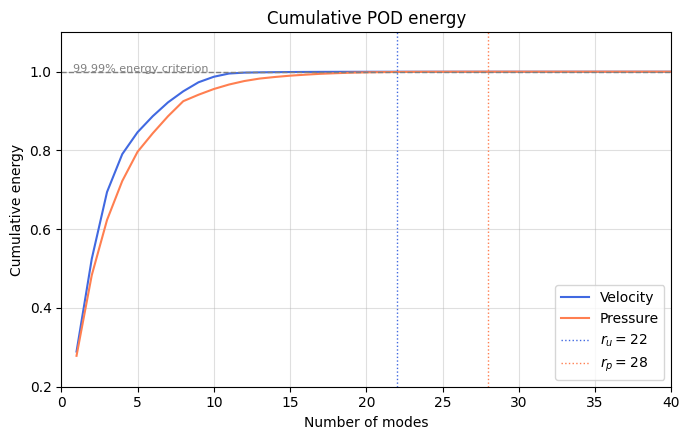

r_u = 22
r_p = 28


In [33]:
import numpy as np
import matplotlib.pyplot as plt

threshold = 0.9999  # 99.99% energy criterion

# Mode numbers
modes_u = np.arange(1, len(energy_u) + 1)
modes_p = np.arange(1, len(energy_p) + 1)

# First number of modes reaching the threshold
r_u = np.argmax(energy_u >= threshold) + 1
r_p = np.argmax(energy_p >= threshold) + 1

plt.figure(figsize=(7, 4.5))

plt.plot(modes_u, energy_u, label="Velocity", color="royalblue")
plt.plot(modes_p, energy_p, label="Pressure", color="coral")

plt.axhline(threshold, color="gray", linestyle="--", linewidth=1)
plt.axvline(r_u, color="royalblue", linestyle=":", linewidth=1, label=rf"$r_u = {r_u}$")
plt.axvline(r_p, color="coral", linestyle=":", linewidth=1, label=rf"$r_p = {r_p}$")

plt.text(
    0.02,
    threshold + 0.00004,
    "99.99% energy criterion",
    transform=plt.gca().get_yaxis_transform(),
    color="gray",
    fontsize=8
)

plt.title("Cumulative POD energy")
plt.xlabel("Number of modes")
plt.ylabel("Cumulative energy")

plt.ylim(0.2, 1.1)
plt.xlim(0, 40)

plt.grid(True, alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("q1_cumulative_pod_energy.png", dpi=300)
plt.show()

print("r_u =", r_u)
print("r_p =", r_p)

In [23]:
def orthonormalize_with_inner_product(V, inner_product, tol=1.0e-12):
    G = V.T @ inner_product @ V
    eigenvalues, eigenvectors = np.linalg.eigh(G)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    keep = eigenvalues > tol * eigenvalues[0]
    if np.sum(keep) < len(eigenvalues):
        print(f"Dropped {len(eigenvalues) - np.sum(keep)} dependent enriched velocity modes")

    V_orth = V @ eigenvectors[:, keep] @ np.diag(1.0 / np.sqrt(eigenvalues[keep]))

    return V_orth

# Enrich velocity basis with supremizer basis and orthonormalize in the velocity norm.
V_u_enriched_raw = np.column_stack([V_u, V_s])
V_u_enriched = orthonormalize_with_inner_product(V_u_enriched_raw, X_u)

V_rom = scipy.linalg.block_diag(V_u_enriched, V_p)

print("V_u_enriched shape:", V_u_enriched.shape)
print("V_rom shape:", V_rom.shape)
print("Enriched velocity orthonormality error:",
      np.linalg.norm(V_u_enriched.T @ X_u @ V_u_enriched - np.eye(V_u_enriched.shape[1])))

V_u_enriched shape: (5932, 50)
V_rom shape: (6761, 78)
Enriched velocity orthonormality error: 1.4084642578819508e-14


In [24]:
# Velocity snapshots: [u_x, u_y]
S_u = snapshot_matrix[:, :2 * speed_n_dofs]

# Pressure snapshots: [p]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]


# Check one snapshot
j = 0

snapshot_u_j = S_u[j, :]
snapshot_p_j = S_p[j, :]

# Project onto POD spaces
coeff_u_j = V_u.T @ X_u @ snapshot_u_j
coeff_p_j = V_p.T @ X_p @ snapshot_p_j

# Reconstruct
reconstruction_u_j = V_u @ coeff_u_j
reconstruction_p_j = V_p @ coeff_p_j

# Relative errors using Euclidean norm for easy interpretation
relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

print("Velocity reconstruction error for snapshot 0:", relative_error_u)
print("Pressure reconstruction error for snapshot 0:", relative_error_p)


# Check all snapshots
velocity_errors = []
pressure_errors = []

for j in range(snapshot_matrix.shape[0]):
    snapshot_u_j = S_u[j, :]
    snapshot_p_j = S_p[j, :]

    coeff_u_j = V_u.T @ X_u @ snapshot_u_j
    coeff_p_j = V_p.T @ X_p @ snapshot_p_j

    reconstruction_u_j = V_u @ coeff_u_j
    reconstruction_p_j = V_p @ coeff_p_j

    relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
    relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

    velocity_errors.append(relative_error_u)
    pressure_errors.append(relative_error_p)

velocity_errors = np.array(velocity_errors)
pressure_errors = np.array(pressure_errors)

print("Velocity max reconstruction error:", np.max(velocity_errors))
print("Velocity mean reconstruction error:", np.mean(velocity_errors))
print("Velocity min reconstruction error:", np.min(velocity_errors))

print("Pressure max reconstruction error:", np.max(pressure_errors))
print("Pressure mean reconstruction error:", np.mean(pressure_errors))
print("Pressure min reconstruction error:", np.min(pressure_errors))

Velocity reconstruction error for snapshot 0: 0.005897709297792357
Pressure reconstruction error for snapshot 0: 0.04743406028527534
Velocity max reconstruction error: 0.01798027774087237
Velocity mean reconstruction error: 0.009684217975743724
Velocity min reconstruction error: 0.0018395418563071362
Pressure max reconstruction error: 0.04743406028527534
Pressure mean reconstruction error: 0.0074436644602790675
Pressure min reconstruction error: 0.0008419260907912931


In [25]:
# Build the reduced assembly matrices using the enriched basis from the previous cell.
J_A_r = V_rom.T @ J_A_Base @ V_rom
J_B_r = V_rom.T @ J_B @ V_rom

def assemble_reduced_stokes_matrix(mu0):
    return mu0 * J_A_r + J_B_r

#newton solver for the reduced order model
def solve_rom(mu0, mu1):
    # Assemble full source vector and project it.
    # This is needed source term is non-affine.
    f_S = assemble_source(mu1)
    f_S_r = V_rom.T @ f_S

    
    J_S_r = assemble_reduced_stokes_matrix(mu0)

    # Initial reduced coefficient vector
    N_rom = V_rom.shape[1]
    a_k = np.zeros(N_rom)

    #iteration settings
    max_iterations = 50
    newton_tol=1e-6
    residual_norm = 1.0
    solution_norm = 1.0
    num_iteration = 1

    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        # Reconstruct full solution from reduced coefficients
        u_full = V_rom @ a_k

        # Split full reconstructed solution
        u_x_numeric = u_full[0:speed_n_dofs]
        u_y_numeric = u_full[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_full[2 * speed_n_dofs:]


        # Assemble nonlinear convection operator using reconstructed full velocity
        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_y_numeric,
            u_x_strong,
            u_y_strong
        )

        # Full convective Jacobian contribution
        J_C = other_ut.make_np_sparse(
            c_operator.convective_operator.operator_dofs,
            [tot_dofs, tot_dofs],
            [0, 0]
        )

        # Full nonlinear RHS contribution
        f_C = np.concatenate([
            c_operator.convective_rhs,
            np.zeros(pressure_n_dofs)
        ])

        # Project nonlinear terms to reduced space
        J_C_r = V_rom.T @ J_C @ V_rom
        f_C_r = V_rom.T @ f_C

        # Reduced Newton RHS
        J_f_r = f_S_r - f_C_r - J_S_r @ a_k

        # Reduced Newton matrix
        J_r = J_S_r + J_C_r

        # Solve reduced Newton correction
        da = np.linalg.solve(J_r, J_f_r)

        # Update reduced coefficients
        a_k = a_k + da

        # Convergence check
        residual_norm = np.linalg.norm(da)
        solution_norm = np.linalg.norm(a_k)



        num_iteration += 1

    # Final reconstructed ROM solution
    u_rom = V_rom @ a_k

    u_x_rom = u_rom[0:speed_n_dofs]
    u_y_rom = u_rom[speed_n_dofs:2 * speed_n_dofs]
    p_rom = u_rom[2 * speed_n_dofs:]

    info = {
        "mu0": mu0,
        "mu1": mu1,
        "iterations": num_iteration - 1,
        "final_ratio": residual_norm / solution_norm,
        "converged": residual_norm <= newton_tol * solution_norm
    }

    return u_rom, u_x_rom, u_y_rom, p_rom, info



In [ ]:
mu0_values = [0.1, 1.0, 2.5, 5.0, 7.5, 10.0]

for mu0 in mu0_values:
    J_S_r_test = assemble_reduced_stokes_matrix(mu0)

    print(f"\nmu0 = {mu0}")
    print("J_S_r shape:", J_S_r_test.shape)
    print("rank:", np.linalg.matrix_rank(J_S_r_test))
    print("condition number:", np.linalg.cond(J_S_r_test))

In [ ]:
mu0_test = 10.0
mu1_test = 2.0

u_rom, u_x_rom, u_y_rom, p_rom, info_rom = solve_rom(mu0_test, mu1_test)
u_fom, u_x_fom, u_y_fom, p_fom, info_fom = solve_fom(mu0_test, mu1_test)

du = u_fom[:2*speed_n_dofs] - u_rom[:2*speed_n_dofs]
u_ref = u_fom[:2*speed_n_dofs]

dp = u_fom[2*speed_n_dofs:] - u_rom[2*speed_n_dofs:]
p_ref = u_fom[2*speed_n_dofs:]

velocity_error = np.sqrt(du.T @ X_u @ du) / np.sqrt(u_ref.T @ X_u @ u_ref)
pressure_error = np.sqrt(dp.T @ X_p @ dp) / np.sqrt(p_ref.T @ X_p @ p_ref)
total_error = np.sqrt(du.T @ X_u @ du + dp.T @ X_p @ dp) / np.sqrt(u_ref.T @ X_u @ u_ref + p_ref.T @ X_p @ p_ref)

print("Total ROM/FOM relative error:", total_error)
print("Velocity ROM/FOM relative error:", velocity_error)
print("Pressure ROM/FOM relative error:", pressure_error)
print("FOM info:", info_fom)
print("ROM info:", info_rom)∏

In [34]:
#testing set
np.random.seed(123)

num_random_test = 200

testing_set = np.random.uniform(
    low=P[:, 0],
    high=P[:, 1],
    size=(num_random_test, P.shape[0])
)

testing_set = np.unique(np.round(testing_set, decimals=12), axis=0)

# Remove any accidental overlap with training
train_rows = {tuple(row) for row in training_set}

testing_set = np.array([
    row for row in testing_set
    if tuple(row) not in train_rows
])

print("testing_set shape:", testing_set.shape)       

testing_set shape: (200, 2)


In [35]:
import time
import pandas as pd
import numpy as np

results = []

for i, (mu0, mu1) in enumerate(testing_set):
    print(f"Testing {i + 1}/{len(testing_set)}: mu0={mu0:.4f}, mu1={mu1:.4f}")

    start = time.perf_counter()
    u_fom_full, ux_fom, uy_fom, p_fom, fom_info = solve_fom(mu0, mu1)
    fom_time = time.perf_counter() - start

    start = time.perf_counter()
    u_rom_full, ux_rom, uy_rom, p_rom, rom_info = solve_rom(mu0, mu1)
    rom_time = time.perf_counter() - start

    # Velocity error
    du = u_fom_full[:2 * speed_n_dofs] - u_rom_full[:2 * speed_n_dofs]
    u_ref = u_fom_full[:2 * speed_n_dofs]

    # Pressure error
    dp = p_fom - p_rom
    p_ref = p_fom

    velocity_error = np.sqrt(du.T @ X_u @ du) / np.sqrt(u_ref.T @ X_u @ u_ref)
    pressure_error = np.sqrt(dp.T @ X_p @ dp) / np.sqrt(p_ref.T @ X_p @ p_ref)

    total_error = np.sqrt(
        du.T @ X_u @ du + dp.T @ X_p @ dp
    ) / np.sqrt(
        u_ref.T @ X_u @ u_ref + p_ref.T @ X_p @ p_ref
    )

    speedup = fom_time / rom_time

    results.append({
        "mu0": mu0,
        "mu1": mu1,
        "velocity_error": velocity_error,
        "pressure_error": pressure_error,
        "total_error": total_error,
        "fom_time": fom_time,
        "rom_time": rom_time,
        "speedup": speedup,
        "fom_iterations": fom_info["iterations"],
        "rom_iterations": rom_info["iterations"],
        "fom_converged": fom_info["converged"],
        "rom_converged": rom_info["converged"],
    })

df_results = pd.DataFrame(results)

df_results

Testing 1/200: mu0=0.1266, mu1=2.9767
Testing 2/200: mu0=0.1350, mu1=1.9618
Testing 3/200: mu0=0.1549, mu1=1.9698
Testing 4/200: mu0=0.1588, mu1=1.7314
Testing 5/200: mu0=0.1735, mu1=2.1032
Testing 6/200: mu0=0.1766, mu1=1.1696
Testing 7/200: mu0=0.2597, mu1=2.1889
Testing 8/200: mu0=0.2623, mu1=2.4424
Testing 9/200: mu0=0.3499, mu1=1.5338
Testing 10/200: mu0=0.3635, mu1=2.8403
Testing 11/200: mu0=0.3903, mu1=2.2718
Testing 12/200: mu0=0.4188, mu1=2.4896
Testing 13/200: mu0=0.5544, mu1=2.4220
Testing 14/200: mu0=0.6157, mu1=1.8136
Testing 15/200: mu0=0.9096, mu1=1.2768
Testing 16/200: mu0=0.9653, mu1=1.6936
Testing 17/200: mu0=1.0118, mu1=1.8674
Testing 18/200: mu0=1.0239, mu1=1.5937
Testing 19/200: mu0=1.0476, mu1=2.7707
Testing 20/200: mu0=1.0607, mu1=1.9238
Testing 21/200: mu0=1.1161, mu1=2.3997
Testing 22/200: mu0=1.1439, mu1=1.4650
Testing 23/200: mu0=1.1485, mu1=1.2618
Testing 24/200: mu0=1.2622, mu1=1.6021
Testing 25/200: mu0=1.2942, mu1=2.6527
Testing 26/200: mu0=1.3268, mu1=2.

,mu0,mu1,velocity_error,pressure_error,total_error,fom_time,rom_time,speedup,fom_iterations,rom_iterations,fom_converged,rom_converged
0,0.126612,2.976691,0.007275,0.011339,0.007376,1.418619,0.906481,1.564973,4,4,True,True
1,0.134969,1.961778,0.006012,0.025690,0.006364,1.429033,0.878427,1.626810,4,4,True,True
2,0.154900,1.969819,0.008331,0.025273,0.008532,1.447797,0.888508,1.629470,4,4,True,True
3,0.158834,1.731438,0.007677,0.031465,0.008856,1.477600,1.002728,1.473580,4,4,True,True
4,0.173521,2.103185,0.006884,0.024111,0.007255,2.530922,1.863127,1.358427,4,4,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
195,9.713357,2.743366,0.018713,0.002602,0.003032,1.234527,1.354933,0.911135,3,3,True,True
196,9.809566,2.369659,0.016723,0.001555,0.002145,2.012179,1.101055,1.827501,3,3,True,True
197,9.836864,1.158732,0.015945,0.008147,0.008274,1.279026,0.686456,1.863231,3,3,True,True
198,9.884452,1.750371,0.015412,0.004158,0.004534,1.154619,0.672540,1.716804,3,3,True,True


In [42]:

print("Mean POD total error:", df_results["total_error"].mean())

print("Max POD total error:", df_results["total_error"].max())

print("Mean vel  error:", df_results["velocity_error"].mean())
print("max vel  error:", df_results["velocity_error"].max())

print("Mean pres  error:", df_results["pressure_error"].mean())
print("max pres  error:", df_results["pressure_error"].max())
df_results.loc[df_results["total_error"].idxmax()]

Mean POD total error: 0.007348542540878654
Max POD total error: 0.016958493445856808
Mean vel  error: 0.015506456008596846
max vel  error: 0.02913681923437826
Mean pres  error: 0.005437342253409753
max pres  error: 0.0314645842592369


,95
mu0,4.365541
mu1,1.98737
velocity_error,0.022047
pressure_error,0.009538
total_error,0.016958
fom_time,1.152883
rom_time,0.692427
speedup,1.664989
fom_iterations,3
rom_iterations,3


In [40]:
#computational cost time
print("Mean fom time:", df_results["fom_time"].max())
print("Mean rom time:", df_results["rom_time"].max())

print("Mean speedup:", df_results["speedup"].mean())


Mean fom time: 2.5309222510004474
Mean rom time: 1.863127489999897
Mean speedup: 1.685142267678237


mu0, mu1: 4.365541 1.98737
total error: 0.0169584805215087
velocity error: 0.022046620152066026
pressure error: 0.009537802175651255
FOM info: {'mu0': 4.365541, 'mu1': 1.98737, 'iterations': 3, 'final_ratio': np.float64(2.834672656927675e-12), 'converged': np.True_}
ROM info: {'mu0': 4.365541, 'mu1': 1.98737, 'iterations': 3, 'final_ratio': np.float64(1.1173753243936468e-13), 'converged': np.True_}


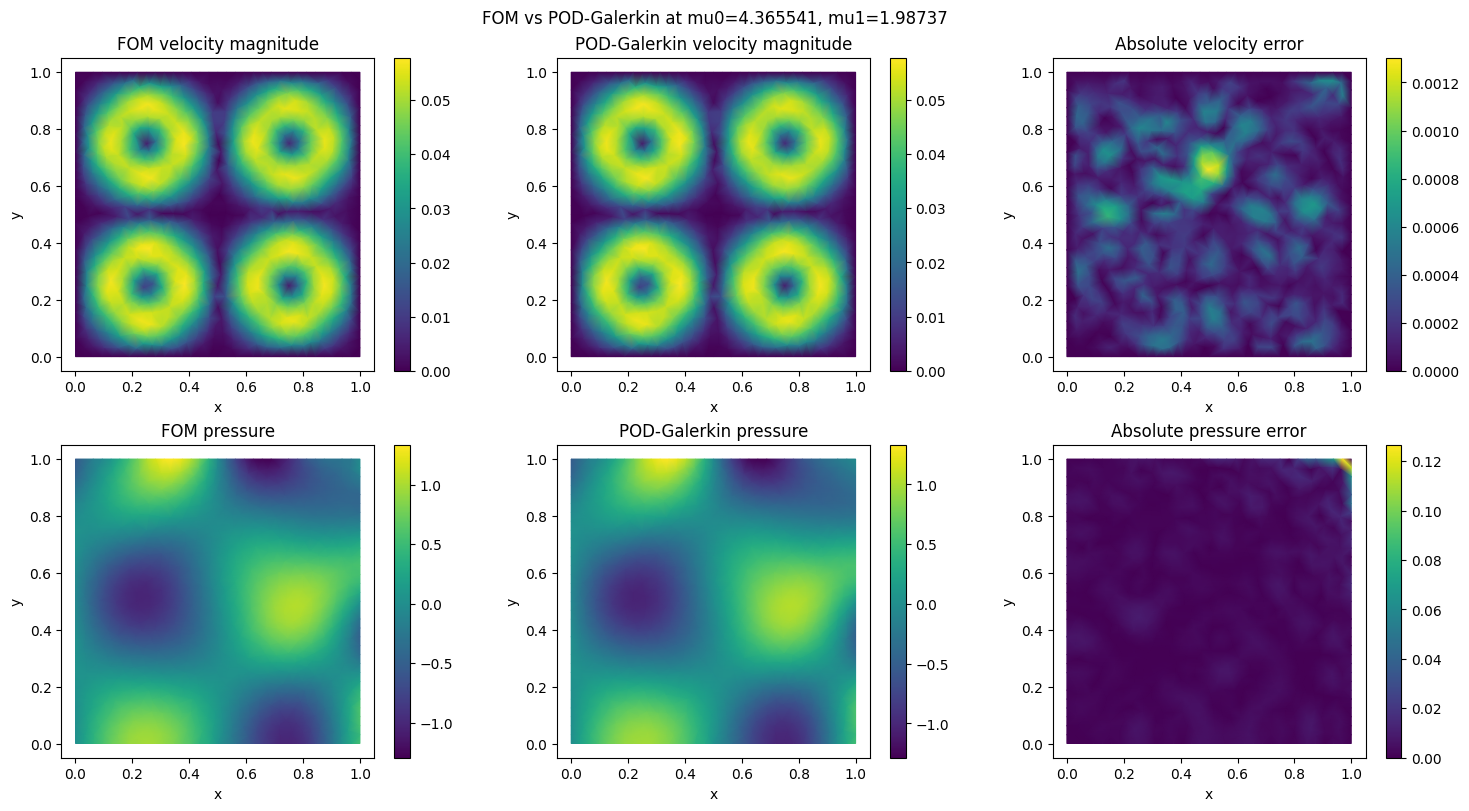

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

mu0_plot = 4.365541
mu1_plot = 1.98737

# Solve FOM and POD-Galerkin ROM
u_fom_full, ux_fom, uy_fom, p_fom, fom_info = solve_fom(mu0_plot, mu1_plot)
u_rom_full, ux_rom, uy_rom, p_rom, rom_info = solve_rom(mu0_plot, mu1_plot)

# Compute relative errors
du = u_fom_full[:2 * speed_n_dofs] - u_rom_full[:2 * speed_n_dofs]
u_ref = u_fom_full[:2 * speed_n_dofs]

dp = p_fom - p_rom
p_ref = p_fom

velocity_error = np.sqrt(du.T @ X_u @ du) / np.sqrt(u_ref.T @ X_u @ u_ref)
pressure_error = np.sqrt(dp.T @ X_p @ dp) / np.sqrt(p_ref.T @ X_p @ p_ref)

total_error = np.sqrt(
    du.T @ X_u @ du + dp.T @ X_p @ dp
) / np.sqrt(
    u_ref.T @ X_u @ u_ref + p_ref.T @ X_p @ p_ref
)

print("mu0, mu1:", mu0_plot, mu1_plot)
print("total error:", total_error)
print("velocity error:", velocity_error)
print("pressure error:", pressure_error)
print("FOM info:", fom_info)
print("ROM info:", rom_info)

def extract_cell0_values(dof_values, dofs_data, strong_values):
    post = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
        mesh,
        dofs_data,
        np.asarray(dof_values, dtype=float),
        np.asarray(strong_values, dtype=float)
    )
    return np.asarray(post.numeric_solution)

# Convert FE DOF solutions to mesh-vertex values.
ux_fom_v = extract_cell0_values(ux_fom, speed_dofs_data, u_x_strong)
uy_fom_v = extract_cell0_values(uy_fom, speed_dofs_data, u_y_strong)
p_fom_v = extract_cell0_values(p_fom, pressure_dofs_data, p_strong)

ux_rom_v = extract_cell0_values(ux_rom, speed_dofs_data, u_x_strong)
uy_rom_v = extract_cell0_values(uy_rom, speed_dofs_data, u_y_strong)
p_rom_v = extract_cell0_values(p_rom, pressure_dofs_data, p_strong)

# Velocity magnitude and pointwise errors.
vel_fom_v = np.sqrt(ux_fom_v**2 + uy_fom_v**2)
vel_rom_v = np.sqrt(ux_rom_v**2 + uy_rom_v**2)
vel_error_v = np.abs(vel_fom_v - vel_rom_v)

p_error_v = np.abs(p_fom_v - p_rom_v)

coordinates = mesh.cell0_ds_coordinates()
x = coordinates[0, :]
y = coordinates[1, :]
triang = mtri.Triangulation(x, y)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

plot_data = [
    (vel_fom_v, "FOM velocity magnitude"),
    (vel_rom_v, "POD-Galerkin velocity magnitude"),
    (vel_error_v, "Absolute velocity error"),
    (p_fom_v, "FOM pressure"),
    (p_rom_v, "POD-Galerkin pressure"),
    (p_error_v, "Absolute pressure error"),
]

for ax, (field, title) in zip(axes.ravel(), plot_data):
    tpc = ax.tripcolor(triang, field, shading="gouraud")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(tpc, ax=ax)

fig.suptitle(f"FOM vs POD-Galerkin at mu0={mu0_plot}, mu1={mu1_plot}")

plt.savefig("q1_fom_vs_pod_galerkin.png", dpi=300, bbox_inches="tight")
plt.show()

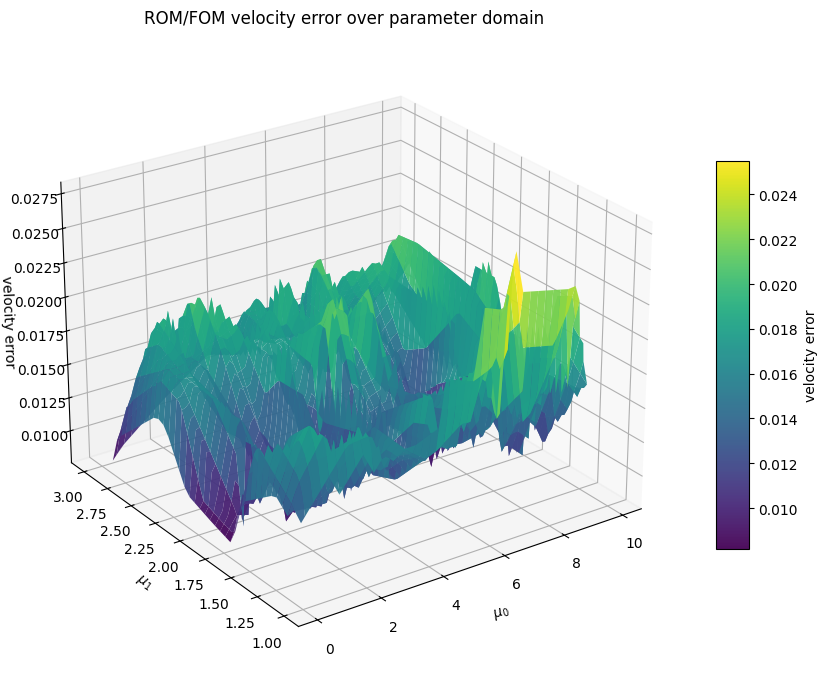

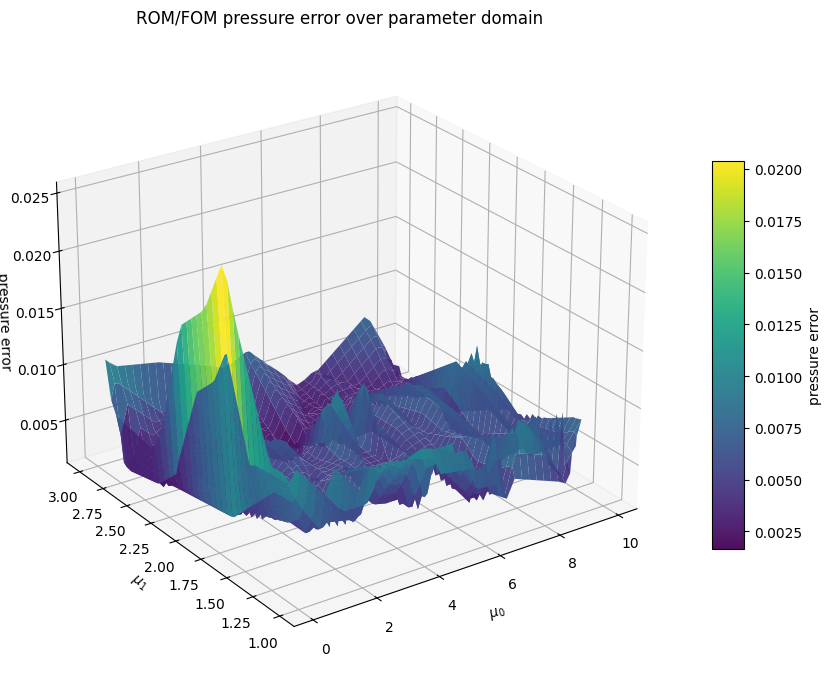

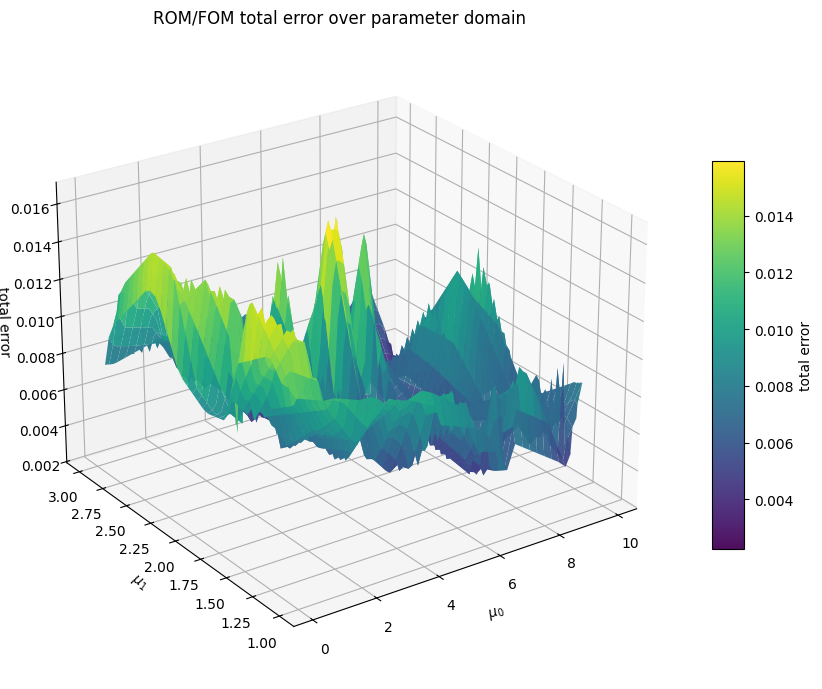

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_error_surface_3d(df, error_column, title):
    mu0 = df["mu0"].to_numpy()
    mu1 = df["mu1"].to_numpy()
    error = df[error_column].to_numpy()

    mu0_grid = np.linspace(mu0.min(), mu0.max(), 80)
    mu1_grid = np.linspace(mu1.min(), mu1.max(), 80)

    MU0, MU1 = np.meshgrid(mu0_grid, mu1_grid, indexing="ij")

    ERROR = griddata(
        points=(mu0, mu1),
        values=error,
        xi=(MU0, MU1),
        method="linear"
    )

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surface = ax.plot_surface(
        MU0,
        MU1,
        ERROR,
        cmap="viridis",
        edgecolor="none",
        alpha=0.95
    )

    ax.set_xlabel(r"$\mu_0$")
    ax.set_ylabel(r"$\mu_1$")
    ax.set_zlabel(error_column.replace("_", " "))
    ax.set_title(title)
    ax.view_init(elev=25, azim=-125)

    fig.colorbar(
        surface,
        ax=ax,
        shrink=0.6,
        aspect=12,
        label=error_column.replace("_", " ")
    )

    plt.tight_layout()
    plt.show()


plot_error_surface_3d(
    df_results,
    "velocity_error",
    "ROM/FOM velocity error over parameter domain"
)

plot_error_surface_3d(
    df_results,
    "pressure_error",
    "ROM/FOM pressure error over parameter domain"
)

plot_error_surface_3d(
    df_results,
    "total_error",
    "ROM/FOM total error over parameter domain"
)